# 📊 EDA for medications

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("..//backend/Training/MasterData/diets.csv")
print("Dataset Uploaded Sucessfully!")

Dataset Uploaded Sucessfully!


## 🔎 Dataset Overview

In [3]:
print("🔹 Dataset Shape:", df.shape)
display(df.head())

🔹 Dataset Shape: (40, 2)


,Disease,Diet
0,Fungal infection,"['Antifungal Diet', 'Probiotics', 'Garlic', 'C..."
1,Allergy,"['Elimination Diet', 'Omega-3-rich foods', 'Vi..."
2,GERD,"['Low-Acid Diet', 'Fiber-rich foods', 'Ginger'..."
3,Chronic cholestasis,"['Low-Fat Diet', 'High-Fiber Diet', 'Lean prot..."
4,Drug Reaction,"['Antihistamine Diet', 'Omega-3-rich foods', '..."


In [4]:
print("\n🔹 Info:")
df.info()


🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Disease  40 non-null     object
 1   Diet     40 non-null     object
dtypes: object(2)
memory usage: 772.0+ bytes


In [5]:
print("\n🔹 Column Names:", df.columns.tolist())
print("\n🔹 Data Types:\n", df.dtypes)
print("\n🔹 Missing Values:\n", df.isnull().sum())
print("\n🔹 Duplicate Rows:", df.duplicated().sum())


🔹 Column Names: ['Disease', 'Diet']

🔹 Data Types:
 Disease    object
Diet       object
dtype: object

🔹 Missing Values:
 Disease    0
Diet       0
dtype: int64

🔹 Duplicate Rows: 0


In [6]:
# Unique values per column
print("\n🔹 Unique Value Counts:")
print(df.nunique())


🔹 Unique Value Counts:
Disease    40
Diet       35
dtype: int64


In [7]:
print("\n🔹 Descriptive Statistics:")
display(df.describe(include="all").transpose())


🔹 Descriptive Statistics:


,count,unique,top,freq
Disease,40,40,Fungal infection,1
Diet,40,35,"['Arthritis Diet', 'Anti-Inflammatory Diet', '...",3



=== Univariate Analysis ===


C:\Users\hp\AppData\Local\Temp\ipykernel_15608\1509616485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


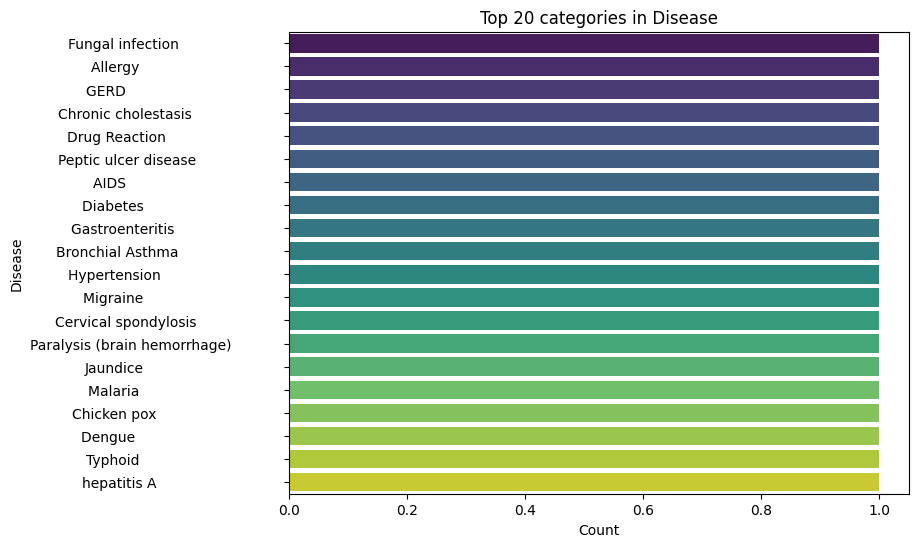

C:\Users\hp\AppData\Local\Temp\ipykernel_15608\1509616485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


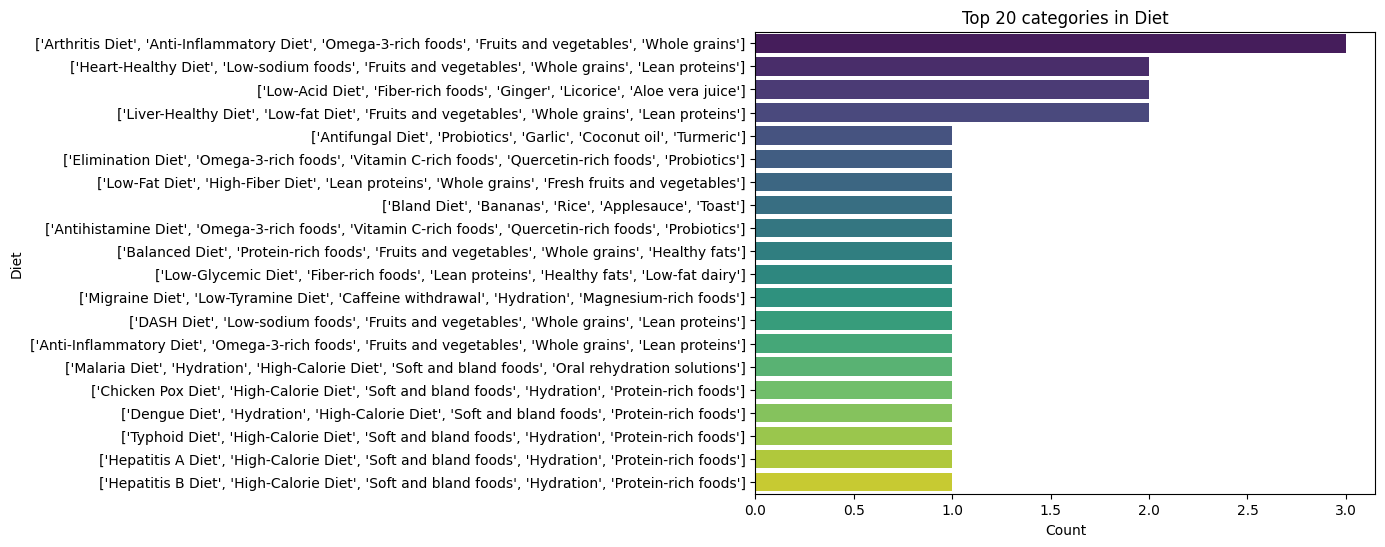

In [8]:
print("\n=== Univariate Analysis ===")

for col in df.columns:
    plt.figure(figsize=(8,6))
    if df[col].dtype == 'object':
        top_vals = df[col].value_counts().head(20)
        sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")
        plt.title(f"Top 20 categories in {col}")
        plt.xlabel("Count")
        plt.ylabel(col)
        plt.show()
    else:
        sns.histplot(df[col], kde=True, bins=30, color="royalblue")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

In [9]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10,6))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

In [10]:
# Crosstab for categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) >= 2:
    for i in range(len(cat_cols)-1):
        ct = pd.crosstab(df[cat_cols[i]], df[cat_cols[i+1]])
        print(f"\n🔹 Crosstab between {cat_cols[i]} and {cat_cols[i+1]}:\n", ct.head())


🔹 Crosstab between Disease and Diet:
 Diet                                     ['Acne Diet', 'Low-Glycemic Diet', 'Hydration', 'Fruits and vegetables', 'Probiotics']  \
Disease                                                                                                                           
(vertigo) Paroymsal Positional Vertigo                                                   0                                        
AIDS                                                                                     0                                        
Acne                                                                                     1                                        
Alcoholic hepatitis                                                                      0                                        
Allergy                                                                                  0                                        

Diet                                     ['


=== Boxplots for Each Feature ===


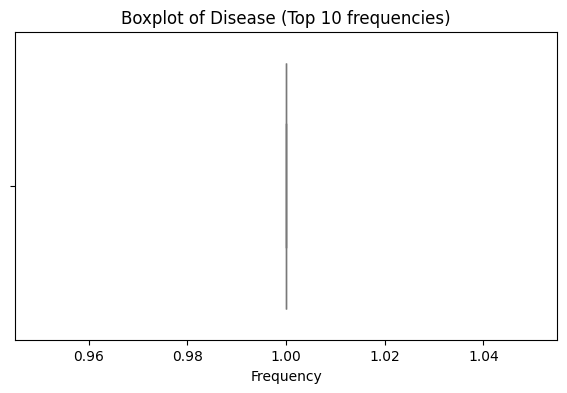

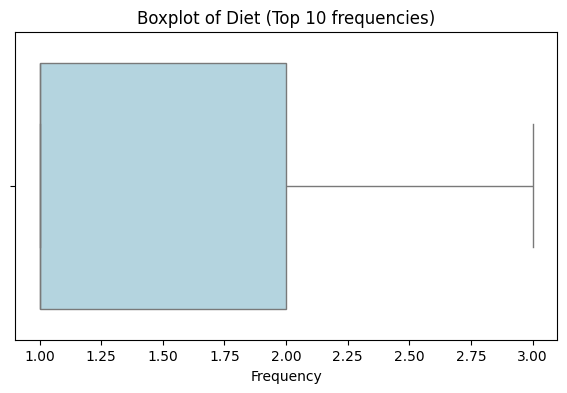

In [11]:
print("\n=== Boxplots for Each Feature ===")

for col in df.columns:
    plt.figure(figsize=(7,4))
    if df[col].dtype != 'object':  # numeric features
        sns.boxplot(x=df[col], color="orange")
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.show()
    else:  # categorical features (frequency counts as boxplot)
        top_vals = df[col].value_counts().head(10)
        sns.boxplot(x=top_vals.values, color="lightblue")
        plt.title(f"Boxplot of {col} (Top 10 frequencies)")
        plt.xlabel("Frequency")
        plt.show()

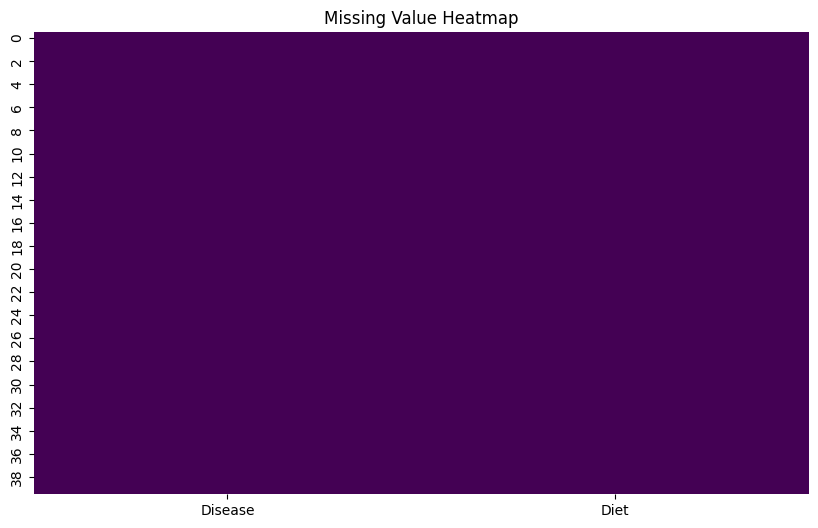

In [12]:
# Missing Data Visualization
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

### EDA Completed Successfully!